# Naive Bayes

Imports and helpers

In [1]:
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.naive_bayes import MultinomialNB
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import numpy as np

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Model Training

model setup and random search 

In [6]:
nb_model = MultinomialNB()
nb_params = {'alpha': loguniform(1e-3, 1e1), 
                 'fit_prior': [True, False]}

Initialize RandomizedSearchCV (3-fold cross-validation acts as our validation set)

In [22]:
nb_search = RandomizedSearchCV(nb_model, nb_params, 
                               n_iter=60, cv=5, scoring='accuracy', 
                               random_state=42, n_jobs=-1, verbose=3)

Extract best models

In [23]:
print("\nTraining Naive Bayes...")
start_time = time.time()
nb_search.fit(X_train, y_train)
nb_train_time = time.time() - start_time
print(f"Naive Bayes training completed in {nb_train_time:.2f}s.")
print("Let's choose the best estimator...")
best_nb = nb_search.best_estimator_
print(f"Best Naive Bayes Params: {nb_search.best_params_}")


Training Naive Bayes...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END alpha=0.03148911647956861, fit_prior=True;, score=0.863 total time=   0.3s
[CV 2/5] END alpha=0.03148911647956861, fit_prior=True;, score=0.861 total time=   0.4s
[CV 3/5] END alpha=0.03148911647956861, fit_prior=True;, score=0.860 total time=   0.6s[CV 3/5] END alpha=0.0054167545832474575, fit_prior=False;, score=0.853 total time=   0.5s

[CV 2/5] END alpha=0.0054167545832474575, fit_prior=False;, score=0.854 total time=   0.5s
[CV 4/5] END alpha=0.03148911647956861, fit_prior=True;, score=0.862 total time=   0.6s
[CV 4/5] END alpha=0.0054167545832474575, fit_prior=False;, score=0.855 total time=   0.3s
[CV 1/5] END alpha=0.0054167545832474575, fit_prior=False;, score=0.857 total time=   0.7s
[CV 5/5] END alpha=0.03148911647956861, fit_prior=True;, score=0.863 total time=   0.7s
[CV 5/5] END alpha=0.0054167545832474575, fit_prior=False;, score=0.856 total time=   0.5s
[CV 1/5] END alpha

## Model Evaluation

Predict on the X_valid 

In [24]:
y_valid_pred = best_nb.predict(X_valid)
print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")

Validation Accuracy: 0.8675


Classification Report

In [25]:
print("Classification Report for model evaluation:")
print(classification_report(y_valid, y_valid_pred, target_names=['Negative', 'Positive']))
print(f"Training Time: {nb_train_time:.4f} seconds")

Classification Report for model evaluation:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     10003
    Positive       0.87      0.86      0.87      9997

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000

Training Time: 16.7848 seconds


confusion matrices

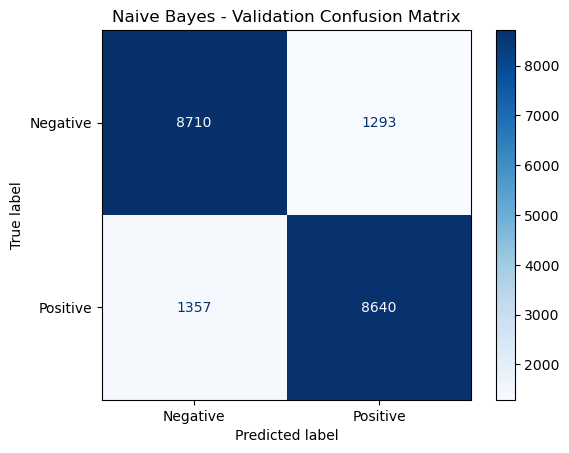

Confusion Matrix:
[[8710 1293]
 [1357 8640]]

True Negatives: 8710
False Positives: 1293
False Negatives: 1357
True Positives: 8640


In [26]:
cm_valid = confusion_matrix(y_valid, y_valid_pred)
ConfusionMatrixDisplay(cm_valid, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Naive Bayes - Validation Confusion Matrix')
plt.savefig('data/predictions/naive_bayes_validation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm_valid}")
print(f"\nTrue Negatives: {cm_valid[0,0]}")
print(f"False Positives: {cm_valid[0,1]}")
print(f"False Negatives: {cm_valid[1,0]}")
print(f"True Positives: {cm_valid[1,1]}")

based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on tr

## Model Testing

Predict on the X_test 

In [27]:
y_test_pred = best_nb.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

Test Accuracy: 0.8683


Classification Report

In [28]:
print("Classification Report for model testing:")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))
print(f"Training Time: {nb_train_time:.4f} seconds")

Classification Report for model testing:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      9966
    Positive       0.87      0.87      0.87     10034

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000

Training Time: 16.7848 seconds


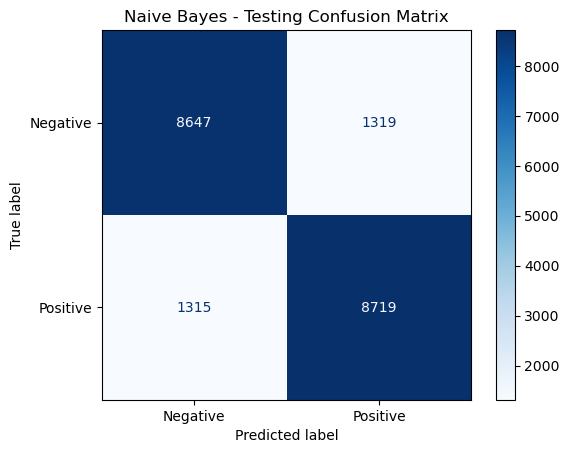

Confusion Matrix:
[[8647 1319]
 [1315 8719]]

True Negatives: 8647
False Positives: 1319
False Negatives: 1315
True Positives: 8719


In [29]:
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Naive Bayes - Testing Confusion Matrix')
plt.savefig('data/predictions/naive_bayes_testing_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm_test}")
print(f"\nTrue Negatives: {cm_test[0,0]}")
print(f"False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}")
print(f"True Positives: {cm_test[1,1]}")

based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on testing dataset

## visualizations (validation and testing Confusion Matrix)

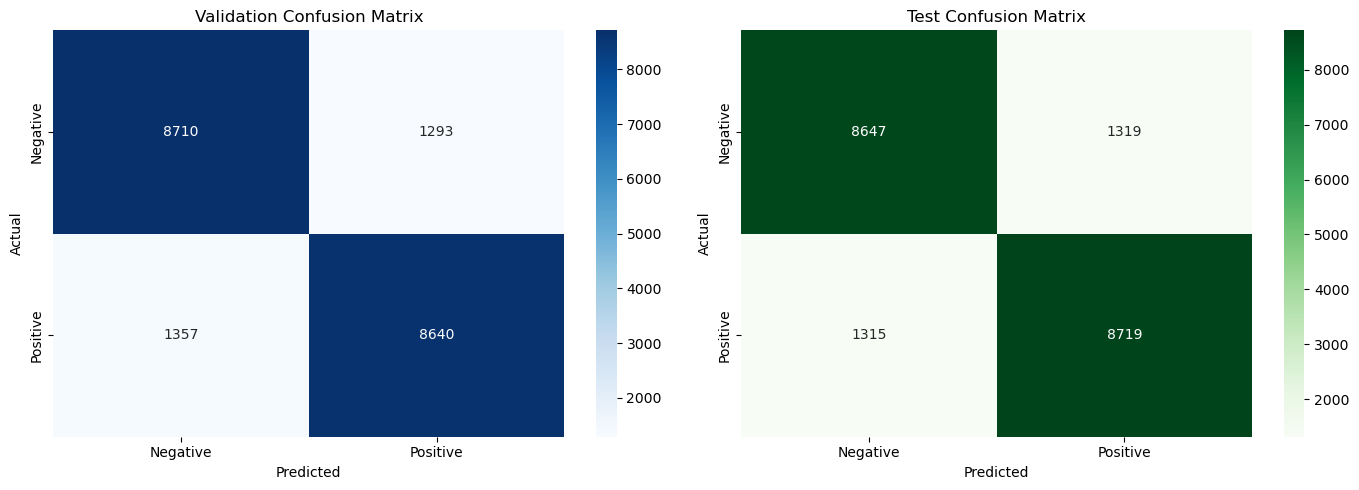

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = best_nb.classes_
ticklabels = ['Negative', 'Positive']

sns.heatmap(confusion_matrix(y_valid, y_valid_pred, labels=classes), 
            annot=True, fmt='d', cmap='Blues', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_test_pred, labels=classes), 
            annot=True, fmt='d', cmap='Greens', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('data/predictions/naive_bayes_valid_test_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Inspection

In [31]:
vec_path = Path('data/vectorizers/tfidf_vectorizer.joblib')

vectorizer_obj = globals().get('vectorizer', None)
if vectorizer_obj is None and vec_path.exists():
    try:
        vectorizer_obj = joblib.load(vec_path)
    except Exception:
        vectorizer_obj = None

if vectorizer_obj is not None and hasattr(best_nb, 'feature_log_prob_'):
    feature_names = (vectorizer_obj.get_feature_names_out()
                     if hasattr(vectorizer_obj, 'get_feature_names_out')
                     else vectorizer_obj.get_feature_names())

    classes = best_nb.classes_
    if 2 in classes and 1 in classes:
        pos_idx = int(np.where(classes == 2)[0][0])
        neg_idx = int(np.where(classes == 1)[0][0])
    else:
        pos_idx, neg_idx = 1, 0 

    diff = best_nb.feature_log_prob_[pos_idx] - best_nb.feature_log_prob_[neg_idx]
    top_pos_idx = diff.argsort()[::-1][:20]
    top_neg_idx = diff.argsort()[:20]

    pos_features = [feature_names[i] for i in top_pos_idx]
    pos_coefs = [round(diff[i], 4) for i in top_pos_idx]
    neg_features = [feature_names[i] for i in top_neg_idx]
    neg_coefs = [round(diff[i], 4) for i in top_neg_idx]

    feature_importance_df = pd.DataFrame({
        'Top Positive Features': pos_features,
        'Pos Weight': pos_coefs,
        'Top Negative Features': neg_features,
        'Neg Weight': neg_coefs
    })
    feature_importance_df.index = feature_importance_df.index + 1

    print("\n--- Model Feature Importance (Top 20) ---")
    try:
        display(feature_importance_df)
    except NameError:
        print(feature_importance_df.to_string())

else:
    print('Vectorizer not found or model lacks feature_log_prob_. Save vectorizer to data/vectorizers/tfidf_vectorizer.joblib to enable feature inspection.')


--- Model Feature Importance (Top 20) ---


,Top Positive Features,Pos Weight,Top Negative Features,Neg Weight
1,highly recommend book,3.2029,waste money,-4.1225
2,highly recommended,2.6958,not waste money,-3.7249
3,also great,2.6765,not waste,-3.6177
4,definitely worth,2.6454,waste time money,-3.5397
5,cannot wait next,2.6054,very disappointed,-3.5288
6,definitely recommend,2.5854,one worst,-3.4053
7,would recommend anyone,2.5630,not worth,-3.3781
8,worth every,2.5487,waste time,-3.3410
9,well worth,2.5397,not waste time,-3.3104
10,very enjoyable,2.5194,waste,-3.2630


## Saving the Model

In [32]:
save(model_base='data/models', model=best_nb, model_name='06_naive_bayes_classifier.joblib')

Saved model 06_naive_bayes_classifier.joblib to data/models/06_naive_bayes_classifier.joblib


{'model': PosixPath('data/models/06_naive_bayes_classifier.joblib')}

## Summary